<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Evaluación y Selección de Modelos: del Protocolo a la Evidencia Estadística 🧪
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 07
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/07%20-%20Seleccion%20de%20Modelos%20y%20Optimizacion/00_Evaluacion_y_Seleccion_de_Modelos.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno abre el **Módulo 07**, que **cierra el Capítulo 2** del libro con las **Secciones 2.10 (*Model Evaluation and Selection*)** y **2.11 (*Metrics for model evaluation*)**. En el [Módulo 03](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/README.md) aprendiste **qué miden** las métricas y a hacer validación cruzada y *GridSearch*; aquí damos el paso siguiente: **¿cuánto puedo creerle a un número?** y **¿cuándo un modelo es de verdad mejor que otro?**. Seguimos el estilo del curso: teoría, **implementación desde cero** y **verificación con `assert`** contra `scikit-learn`/`SciPy`.

Al terminar podrás:

1. **Aplicar el protocolo completo** (entrenamiento / validación / prueba **sellada**, con **líneas base**) y explicar por qué la prueba se toca **una sola vez**.
2. **Cuantificar la incertidumbre** de una métrica con **intervalos de confianza por *bootstrap*** (desde cero) y compararlos con **Wilson** y **Wald**, midiendo su **cobertura real**.
3. **Comparar dos modelos con rigor**: *t* pareada, la **corrección de Nadeau y Bengio (2003)**, **McNemar** y la **prueba 5×2cv de Dietterich (1998)** (en su versión *t* y en su variante *F* combinada de Alpaydin, 1999), todas implementadas desde cero y verificadas.
4. **Demostrar por simulación** que la *t* pareada ingenua sobre pliegues de CV es **demasiado optimista** (error tipo I muy superior al 5 %).
5. **Evaluar probabilidades**, no solo etiquetas: **log loss**, **Brier**, **diagramas de confiabilidad** y **ECE**; **calibrar** con **Platt** e **isotónica** (`CalibratedClassifierCV`).
6. **Usar curvas de aprendizaje** para diagnosticar **sesgo alto** frente a **varianza alta**.
7. **Elegir la métrica correcta** con una **tabla guía** por tipo de problema (clasificación, regresión, *clustering*, *ranking*, refuerzo) y un **árbol de decisión** guiado por el **costo del negocio**.

> 📍 **Dónde estamos:** Módulo 07, cuaderno 1 de 4. Siguientes: [Validación cruzada avanzada](01_Validacion_Cruzada_Avanzada.ipynb) → [Random Search y GridSearch](02_Random_Search_y_GridSearch.ipynb) → [Optimización bayesiana](03_Optimizacion_Bayesiana.ipynb).

> 🔗 **Para no repetir:** matriz de confusión, *accuracy*, *precision*/*recall*, $F_\beta$, ROC-AUC y PR-AUC, y el umbral por costo están en el [Módulo 03, cuaderno 00](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb); las métricas de regresión en el [cuaderno 01](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/01_Metricas_de_Regresion.ipynb); *k*-fold, validación cruzada, fuga de datos y *GridSearch* en el [cuaderno 02](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/02_Validacion_Cruzada_y_GridSearch.ipynb); las métricas de *clustering* en el [Módulo 04, cuaderno 04](../04%20-%20Clustering%20No%20Supervisado/04_Metricas_de_Clustering.ipynb). Aquí **se usan y se enlazan**, no se repiten.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 1 (*Testing and Validating*, *Hyperparameter Tuning and Model Selection*, *Data Mismatch*), Cap. 2 (*Better Evaluation Using Cross-Validation*) y Cap. 3 (medidas de desempeño en clasificación) (disponible en `Machine Learning/Libros/`; títulos de sección verificados contra el índice del PDF).
- *Python Machine Learning* — **Sebastian Raschka** (Packt, 2015). Cap. 6 (*Learning Best Practices for Model Evaluation and Hyperparameter Tuning*): *Debugging algorithms with learning and validation curves* (*Diagnosing bias and variance problems with learning curves*), *Algorithm selection with nested cross-validation* y *Looking at different performance evaluation metrics* (disponible en `Machine Learning/Libros/`; verificado contra el PDF).
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman**. Cap. 7 (*Model Assessment and Selection*): error de generalización, optimismo del error de entrenamiento y reparto entrenamiento/validación/prueba *(capítulo citado de memoria, verificar)*.
- Dietterich, T. G. (1998), *Approximate statistical tests for comparing supervised classification learning algorithms*, **Neural Computation** 10(7): 1895–1923 · Alpaydin, E. (1999), *Combined 5×2 cv F test for comparing supervised classification learning algorithms*, **Neural Computation** 11(8): 1885–1892 *(ambos citados de memoria, verificar)*.
- Nadeau, C. & Bengio, Y. (2003), *Inference for the generalization error*, **Machine Learning** 52: 239–281 *(citado de memoria, verificar)*.
- Efron, B. & Tibshirani, R. (1993), *An Introduction to the Bootstrap*, Chapman & Hall *(citado de memoria, verificar)*.
- Niculescu-Mizil, A. & Caruana, R. (2005), *Predicting good probabilities with supervised learning*, **ICML** · Platt, J. (1999), *Probabilistic outputs for support vector machines…* · Guo, C. et al. (2017), *On calibration of modern neural networks*, **ICML** *(todos citados de memoria, verificar)*.
- Raschka, S. (2018), *Model evaluation, model selection, and algorithm selection in machine learning*, arXiv:1811.12808 *(citado de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html) · [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) · [Learning curves](https://scikit-learn.org/stable/modules/learning_curve.html)
- [SciPy: `scipy.stats.binomtest`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html) · [`ttest_rel`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html)

---
## 1. El Protocolo de Evaluación: Desarrollo, Prueba Sellada y Líneas Base 🔐

### 1.1 Evaluar y seleccionar son dos trabajos distintos

Hastie, Tibshirani y Friedman (Cap. 7) separan dos objetivos que **exigen datos diferentes**:

- ***Model selection*** (selección): comparar modelos o hiperparámetros y **elegir** uno. Gasta información: cada comparación **filtra** a la selección algo del conjunto usado.
- ***Model assessment*** (evaluación): estimar el **error de generalización** $\text{Err}=\mathbb E[L(Y,\hat f(\mathbf X))]$ del modelo **ya elegido**. Solo es insesgada si los datos **no influyeron en ninguna decisión**.

El error de entrenamiento es un estimador **optimista** de $\text{Err}$ (el modelo se ajustó a esos mismos datos); el conjunto de **validación** se «gasta» al elegir (el máximo de varios puntajes es optimista, como vimos en el [Módulo 03](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/02_Validacion_Cruzada_y_GridSearch.ipynb)); solo la **prueba** guardada bajo llave da una estimación honesta. Géron (Cap. 1) lo llama *holdout validation* y añade el conjunto *train-dev* para detectar **desajuste entre los datos de entrenamiento y los de producción** (*data mismatch*).

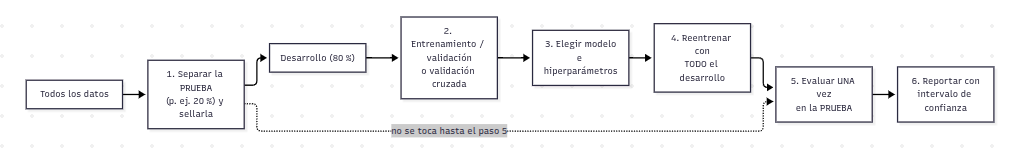

### 1.2 Las líneas base: el piso que hay que superar

Un número como «*accuracy* = 0.95» **no significa nada** sin una referencia. Antes de entrenar nada complejo se calcula una **línea base** (*baseline*):

| Problema | Línea base típica | Qué te dice |
|---|---|---|
| Clasificación | Predecir **siempre la clase mayoritaria**; predecir **al azar según la prevalencia** | Con 63 % de positivos, acertar el 63 % **no** es aprender |
| Regresión | Predecir la **media** (o mediana) del entrenamiento (da $R^2\approx0$) | $R^2$ mide cuánto mejora el modelo a ese piso |
| Series de tiempo | **Persistencia**: «mañana = hoy» | Muchos modelos sofisticados **no** la superan |
| Cualquiera | Un modelo **simple y barato** (regresión lineal/logística) | Si el complejo no lo supera por un margen claro, **quédate con el simple** |

Implementamos el protocolo sobre *Breast Cancer*: separamos la **prueba sellada** (una clase `PruebaSellada` que **lanza un error** si intentas usarla dos veces: una forma poco sutil de recordar la regla), comparamos candidatos y líneas base sobre la **validación**, y evaluamos al elegido **una sola vez**.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
from scipy import stats
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, log_loss,
                             brier_score_loss, ndcg_score)
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]
print(f"Entorno listo | numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__}")

In [ ]:
# ============================================================
# 1. El protocolo: desarrollo / PRUEBA sellada, con lineas base
# ============================================================
bc = load_breast_cancer()
X, y = bc.data, bc.target                                    # 569 pacientes, 30 variables; y = 1 si el tumor es benigno (63 %)

# Paso 1: separar la PRUEBA (20 %) antes de mirar nada. Se "sella": solo se podra evaluar una vez.
X_dev, X_te, y_dev, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
# Paso 2: dentro del desarrollo, entrenamiento (60 % del total) y validacion (20 %) para comparar candidatos.
X_tr, X_va, y_tr, y_va = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
print(f"Entrenamiento = {len(y_tr)} | validación = {len(y_va)} | prueba = {len(y_te)}  (60 / 20 / 20)")


class PruebaSellada:
    """Guarda la prueba y solo deja usarla UNA vez: protege contra la tentacion de ajustar mirandola."""
    def __init__(self, X, y):
        self._X, self._y, self.usada = X, y, False

    def evaluar(self, modelo):
        if self.usada:
            raise RuntimeError("La prueba ya se usó: cualquier decisión posterior la contaminaría.")
        self.usada = True
        return self._y, modelo.predict(self._X), modelo.predict_proba(self._X)[:, 1]


prueba = PruebaSellada(X_te, y_te)

# Candidatos: dos LINEAS BASE (sin aprender nada de X) y cuatro modelos reales
candidatos = {
    "Base: siempre la clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Base: al azar según la prevalencia": DummyClassifier(strategy="stratified", random_state=SEED),
    "Regresión logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "k-NN (k = 5)": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(probability=True, random_state=SEED)),
    "Bosque aleatorio": RandomForestClassifier(n_estimators=100, random_state=SEED),
}
filas = {}
for nombre, m in candidatos.items():
    m.fit(X_tr, y_tr)
    pred, prob = m.predict(X_va), m.predict_proba(X_va)[:, 1]
    filas[nombre] = {"accuracy": accuracy_score(y_va, pred), "accuracy balanceado": balanced_accuracy_score(y_va, pred),
                     "F1": f1_score(y_va, pred), "ROC-AUC": roc_auc_score(y_va, prob)}
tabla_val = pd.DataFrame(filas).T
display(tabla_val.round(3))

prev = y_va.mean()
assert np.isclose(tabla_val.loc["Base: siempre la clase mayoritaria", "accuracy"], max(prev, 1 - prev))      # el 'modelo' trivial acierta la prevalencia
assert np.isclose(tabla_val.loc["Base: siempre la clase mayoritaria", "accuracy balanceado"], 0.5)           # ... pero su accuracy balanceado es el del azar
assert abs(tabla_val.loc["Base: al azar según la prevalencia", "ROC-AUC"] - 0.5) < 0.15                       # sin senal: AUC ~ 0.5 (sus "probabilidades" son 0/1 al azar)

# Seleccion: mejor candidato REAL segun la validacion; se reentrena con TODO el desarrollo (entrenamiento + validacion)
reales = tabla_val.drop(index=[n for n in tabla_val.index if n.startswith("Base")])
elegido = reales["ROC-AUC"].idxmax()
final = candidatos[elegido].fit(X_dev, y_dev)
y_real, y_hat, p_hat = prueba.evaluar(final)                  # <- UNICA mirada a la prueba
print(f"\nElegido por la validación: {elegido} (AUC en validación = {reales['ROC-AUC'].max():.3f})")
print(f"En la PRUEBA (una sola vez): accuracy = {accuracy_score(y_real, y_hat):.3f} | F1 = {f1_score(y_real, y_hat):.3f} | ROC-AUC = {roc_auc_score(y_real, p_hat):.3f}")
try:
    prueba.evaluar(final)
except RuntimeError as e:
    print("Segundo intento de evaluar la prueba ->", e)
print(f"\nPiso a superar: la línea base 'clase mayoritaria' acierta {tabla_val.iloc[0]['accuracy']:.1%} con accuracy balanceado {tabla_val.iloc[0]['accuracy balanceado']:.2f}; un modelo que no la supere de forma clara no aprendió nada útil.")
print("Con solo 114 ejemplos de validación, las diferencias de 1-2 puntos entre candidatos NO son fiables: la sección siguiente cuantifica la incertidumbre.")

---
## 2. ¿Cuánto Pesa un Número? Intervalos de Confianza por *Bootstrap* 📏

Una métrica calculada sobre $n$ ejemplos es **una realización** de una variable aleatoria: con otra muestra de prueba habría salido otro valor. Un **intervalo de confianza** (IC) comunica ese ruido. Para el *accuracy* hay fórmulas cerradas (binomial), pero para métricas como el **ROC-AUC** o el **$F_1$** no; el **bootstrap** (Efron, 1979; Efron & Tibshirani, 1993) sirve para **cualquier** métrica:

1. Dado el conjunto de prueba $\{(y_i,s_i)\}_{i=1}^n$, genera $B$ **remuestras con reemplazo** de tamaño $n$.
2. Calcula la métrica $m^{*b}$ en cada una.
3. El **IC percentil** al $1-\alpha$ es $[\,q_{\alpha/2},\,q_{1-\alpha/2}\,]$ de $\{m^{*b}\}$.

Para una proporción $\hat p=k/n$ hay dos fórmulas clásicas:

$$\text{Wald: } \hat p\pm z\sqrt{\tfrac{\hat p(1-\hat p)}{n}},\qquad \text{Wilson: } \frac{\hat p+\frac{z^2}{2n}}{1+\frac{z^2}{n}}\pm\frac{z}{1+\frac{z^2}{n}}\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}},$$

con $z=1.96$ para el 95 %. Wald es la fórmula de los libros de texto, pero tiene **cobertura real inferior a la nominal** con $n$ pequeño o $\hat p$ cerca de 0 o 1. Implementamos Wilson desde cero (verificado contra `scipy.stats.binomtest`) y **medimos la cobertura real** de los tres métodos simulando miles de pruebas con un $p$ verdadero **conocido**. Observa además la regla $\text{ancho}\propto1/\sqrt n$: **cuadruplicar** la prueba solo **reduce a la mitad** el intervalo.

In [ ]:
# ============================================================
# 2. Intervalos de confianza por bootstrap (DESDE CERO) y comparacion con formulas cerradas
# ============================================================
def ic_bootstrap(y_verd, s, metrica, B=2000, alpha=0.05, seed=SEED):
    """IC percentil: remuestrea los n pares (y, s) CON reemplazo B veces y recalcula la metrica en cada remuestra."""
    rng = np.random.default_rng(seed)
    n = len(y_verd)
    est = np.empty(B)
    for b in range(B):
        i = rng.integers(0, n, n)
        est[b] = metrica(y_verd[i], s[i])
    return np.percentile(est, [100 * alpha / 2, 100 * (1 - alpha / 2)]), est


def ic_wilson(k, n, alpha=0.05):
    """Intervalo de Wilson para una proporcion k/n (formula cerrada)."""
    z, p = stats.norm.ppf(1 - alpha / 2), k / n
    centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    mitad = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centro - mitad, centro + mitad


def ic_wald(k, n, alpha=0.05):
    z, p = stats.norm.ppf(1 - alpha / 2), k / n
    return p - z * np.sqrt(p * (1 - p) / n), p + z * np.sqrt(p * (1 - p) / n)


# --- (a) Sobre la prueba del cuaderno (n = 114) ---
n_te, k_ok = len(y_real), int((y_real == y_hat).sum())
(lo_a, hi_a), est_a = ic_bootstrap(y_real, y_hat, lambda a, b: (a == b).mean())
(lo_u, hi_u), est_u = ic_bootstrap(y_real, p_hat, roc_auc_score)
lo_w, hi_w = ic_wilson(k_ok, n_te)
ref = stats.binomtest(k_ok, n_te).proportion_ci(confidence_level=0.95, method="wilson")
assert np.allclose([lo_w, hi_w], [ref.low, ref.high])                            # Wilson desde cero == scipy
display(pd.DataFrame({"estimación": [k_ok / n_te, roc_auc_score(y_real, p_hat)],
                      "IC 95 % bootstrap": [f"[{lo_a:.3f}, {hi_a:.3f}]", f"[{lo_u:.3f}, {hi_u:.3f}]"],
                      "IC 95 % Wilson (solo accuracy)": [f"[{lo_w:.3f}, {hi_w:.3f}]", "—"]},
                     index=["accuracy", "ROC-AUC"]).round(3))
print(f"Con n = {n_te}, el IC del accuracy mide ≈ {100 * (hi_a - lo_a):.1f} puntos de ancho: una diferencia de 1 punto entre modelos NO es distinguible del ruido.")

# --- (b) Cobertura REAL de los intervalos (simulacion con p verdadera = 0.90) ---
rng = np.random.default_rng(SEED)
R, B, p_ver = 500, 1000, 0.90
filas = []
for n in (30, 100, 400):
    k = rng.binomial(n, p_ver, R)
    phat = k / n
    wald = np.array([ic_wald(ki, n) for ki in k]); wil = np.array([ic_wilson(ki, n) for ki in k])
    # Remuestrear un vector de n aciertos/fallos con reemplazo equivale a una Binomial(n, p_hat) / n
    boots = rng.binomial(n, phat[:, None], size=(R, B)) / n
    bo = np.percentile(boots, [2.5, 97.5], axis=1).T
    cubre = lambda iv: np.mean((iv[:, 0] <= p_ver) & (p_ver <= iv[:, 1]))
    filas.append({"n": n, "Wald": cubre(wald), "Wilson": cubre(wil), "bootstrap percentil": cubre(bo)})
cob = pd.DataFrame(filas).set_index("n")
display(cob.round(3))
assert (cob["Wilson"] > 0.90).all()                                              # Wilson mantiene cobertura cercana a 95 %

# --- (c) Cuanto cuesta reducir la incertidumbre: el ancho baja como 1/sqrt(n) ---
ns = np.array([50, 100, 400, 1600, 6400])
ancho = 2 * 1.96 * np.sqrt(0.95 * 0.05 / ns)
assert np.allclose(ancho[2:] / ancho[1:-1], 0.5)                                 # cuadruplicar n  ->  mitad de ancho
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(est_a, bins=np.arange(-0.5, n_te + 1.5) / n_te, color="#93c5fd", edgecolor="white")      # un bin por valor posible (k/n)
axes[0].axvline(k_ok / n_te, color="#dc2626", lw=2, label=f"Accuracy observado = {k_ok / n_te:.3f}")
axes[0].axvspan(lo_a, hi_a, color="#f59e0b", alpha=0.25, label="IC 95 % bootstrap")
axes[0].set_xlabel("Accuracy en la remuestra bootstrap"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title(f"2 000 remuestras de la prueba (n = {n_te})", fontweight="bold"); axes[0].legend(fontsize=8)
axes[1].loglog(ns, 100 * ancho, "o-", color="#2563eb", lw=2)
for n_, a_ in zip(ns, ancho): axes[1].annotate(f"{100 * a_:.1f} pts", (n_, 100 * a_), textcoords="offset points", xytext=(6, 6), fontsize=8)
axes[1].set_xlabel("Tamaño del conjunto de prueba $n$"); axes[1].set_ylabel("Ancho del IC 95 % del accuracy (puntos %)")
axes[1].set_title("Para ver 1 punto de diferencia hace falta una prueba enorme (accuracy ≈ 95 %)", fontweight="bold", fontsize=9)
plt.tight_layout(); plt.show()
print("Lectura: Wilson (y el bootstrap) mantienen cobertura cercana al 95 %; la fórmula de Wald, la más popular, tiende a quedarse corta cuando n es pequeño y p cercano a 1.")

---
##### 🛠️ Práctica 1: Un intervalo de confianza para el $F_1$

En la Sección 2 el *bootstrap* dio un intervalo para el *accuracy* y para el ROC-AUC de la prueba sellada. El $F_1$ tampoco tiene fórmula cerrada sencilla, pero el *bootstrap* sirve para **cualquier** métrica. Usa `y_real`, `y_hat`, `ic_bootstrap()` y `f1_score` (ya importado):

1. Calcula el $F_1$ observado en la prueba y guárdalo en `f1_obs`.
2. Obtén su intervalo con `ic_bootstrap(y_real, y_hat, f1_score, B=200)`; guarda el intervalo en `lo_f1, hi_f1` y las remuestras en `est_f1`.
3. Guarda el ancho del intervalo en `ancho_f1` y compáralo con el del *accuracy* (`hi_a - lo_a`, calculado en la Sección 2): imprime ambos.
4. Verifica con `assert` que `f1_obs` cae dentro de `[lo_f1, hi_f1]` y que `est_f1` tiene exactamente 200 remuestras.

In [ ]:
# Escribe tu código aquí

# f1_obs = f1_score(..., ...)
# (lo_f1, hi_f1), est_f1 = ic_bootstrap(..., ..., f1_score, B=200)
# ancho_f1 = hi_f1 - lo_f1


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
f1_obs = f1_score(y_real, y_hat)

# El bootstrap remuestrea los n pares (y, prediccion) con reemplazo y recalcula F1 en cada remuestra
(lo_f1, hi_f1), est_f1 = ic_bootstrap(y_real, y_hat, f1_score, B=200)
ancho_f1 = hi_f1 - lo_f1

print(f"F1 observado = {f1_obs:.3f} | IC 95 % bootstrap = [{lo_f1:.3f}, {hi_f1:.3f}] | ancho = {100 * ancho_f1:.1f} puntos")
print(f"Ancho del IC del accuracy (Seccion 2) = {100 * (hi_a - lo_a):.1f} puntos")

assert lo_f1 <= f1_obs <= hi_f1
assert len(est_f1) == 200
print("El F1 tambien viene con su margen de error: reportalo siempre junto al valor puntual.")
```
</details>

---


---
## 3. Comparar Modelos con Rigor: Pruebas Pareadas, McNemar y 5×2cv ⚖️

### 3.1 El problema

Tienes dos modelos $A$ y $B$ y una estimación de su error por validación cruzada. Si $A$ saca 0.961 y $B$ 0.953, ¿$A$ es mejor? Se necesita una **prueba de hipótesis** sobre $H_0:\ \mathbb E[\text{Err}_A-\text{Err}_B]=0$. Tres familias:

**(a) *t* pareada sobre pliegues.** Con las diferencias $d_j=\text{acc}_A^{(j)}-\text{acc}_B^{(j)}$ en $k$ pliegues (**los mismos para ambos modelos**: de ahí lo «pareado»):

$$t=\frac{\bar d}{\sqrt{s_d^2/k}}\ \sim t_{k-1}\quad\text{(solo si los }d_j\text{ fueran independientes).}$$

**Pero no lo son.** Los conjuntos de entrenamiento de distintos pliegues **se solapan** y los de prueba se reutilizan, así que las $d_j$ están **positivamente correlacionadas** y $s_d^2/k$ **subestima** la varianza de $\bar d$. Nadeau y Bengio (2003) lo corrigen: si la correlación entre dos diferencias es $\rho\approx\frac{n_{\text{prueba}}}{n_{\text{prueba}}+n_{\text{ent}}}$, entonces $\operatorname{Var}(\bar d)\approx\big(\tfrac1k+\tfrac{\rho}{1-\rho}\big)\sigma^2$ y

$$t_{\text{corr}}=\frac{\bar d}{\sqrt{\big(\tfrac1k+\tfrac{n_{\text{prueba}}}{n_{\text{ent}}}\big)\,s_d^2}}\ \sim t_{k-1},\qquad \frac{n_{\text{prueba}}}{n_{\text{ent}}}=\frac1{K-1}\ \text{en }K\text{-fold}.$$

**(b) Prueba de McNemar** (una sola partición entrenamiento/prueba). Solo importan los ejemplos donde los modelos **discrepan**: $b$ = $A$ acierta y $B$ falla; $c$ = $A$ falla y $B$ acierta. Bajo $H_0$, $b\sim\text{Bin}(b+c,\tfrac12)$, de donde un *p*-valor **exacto** $2\,P(\text{Bin}(b+c,\tfrac12)\le\min(b,c))$ y la versión asintótica con corrección de continuidad $\chi^2=\frac{(|b-c|-1)^2}{b+c}\sim\chi^2_1$. Su límite: **ignora la variabilidad por el conjunto de entrenamiento** (un solo entrenamiento).

**(c) Prueba 5×2cv (Dietterich, 1998).** Cinco repeticiones de validación cruzada de **2 pliegues**; con $p_i^{(j)}$ la diferencia de error en el pliegue $j$ de la repetición $i$, $\bar p_i=\frac{p_i^{(1)}+p_i^{(2)}}2$ y $s_i^2=\sum_j(p_i^{(j)}-\bar p_i)^2$, la ***t* 5×2cv** de Dietterich usa solo $p_1^{(1)}$ en el numerador, $t=\dfrac{p_1^{(1)}}{\sqrt{\frac15\sum_i s_i^2}}\sim t_5$. Alpaydin (1999) propuso una variante, la ***F* 5×2cv combinada**, que aprovecha las **10** diferencias y suele tener más potencia:

$$F=\frac{\sum_{i=1}^{5}\sum_{j=1}^{2}\big(p_i^{(j)}\big)^2}{2\sum_{i=1}^{5}s_i^2}\ \approx\ F_{10,5}.$$

Dietterich (1998) comparó varias pruebas y concluyó que **McNemar** (cuando solo se puede entrenar una vez) y la **5×2cv** son las que mantienen el **error tipo I controlado**, mientras que la *t* sobre remuestras aleatorias lo infla mucho *(resultado citado de memoria, verificar)*. Implementamos las pruebas, las **verificamos** y luego medimos su **error tipo I** simulando un mundo donde **no hay diferencia real**.

In [ ]:
# ============================================================
# 3. Pruebas para comparar modelos, DESDE CERO: t pareada, Nadeau-Bengio, McNemar, 5x2cv
# ============================================================
def t_ingenua(d):
    """t pareada clasica sobre k diferencias d_j: t = media / sqrt(var / k). Supone diferencias INDEPENDIENTES (falso en CV)."""
    d = np.asarray(d, float); k = len(d); s2 = d.var(ddof=1)
    if s2 == 0: return 0.0, 1.0
    t = d.mean() / np.sqrt(s2 / k)
    return t, 2 * stats.t.sf(abs(t), k - 1)


def t_corregida(d, razon_test_ent):
    """Nadeau & Bengio (2003): t = media / sqrt((1/k + n_test/n_ent) * var).  Para k-fold, n_test/n_ent = 1/(k-1)."""
    d = np.asarray(d, float); k = len(d); s2 = d.var(ddof=1)
    if s2 == 0: return 0.0, 1.0
    t = d.mean() / np.sqrt((1 / k + razon_test_ent) * s2)
    return t, 2 * stats.t.sf(abs(t), k - 1)


def mcnemar(b, c):
    """b = A acierta y B falla; c = A falla y B acierta. Devuelve (chi2 con correccion de continuidad, p asintotico, p exacto)."""
    if b + c == 0: return 0.0, 1.0, 1.0
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    return chi2, stats.chi2.sf(chi2, 1), min(1.0, 2 * stats.binom.cdf(min(b, c), b + c, 0.5))


def t_5x2cv(p):
    """t 5x2cv de Dietterich (1998). p[i, j] = diferencia de error en el pliegue j (0/1) de la repeticion i (matriz 5x2).
    t = p[0, 0] / sqrt(media de s_i^2) ~ t(5): usa SOLO la primera diferencia de la primera repeticion en el numerador."""
    p = np.asarray(p, float)
    s2 = ((p - p.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)                   # s_i^2 = (p_i1 - pbar_i)^2 + (p_i2 - pbar_i)^2
    if s2.mean() == 0: return 0.0, 1.0
    t = p[0, 0] / np.sqrt(s2.mean())
    return t, 2 * stats.t.sf(abs(t), 5)


def f_5x2cv(p):
    """Prueba F combinada 5x2cv (Alpaydin, 1999), variante de la t de Dietterich que usa las 10 diferencias. F ~ F(10, 5)."""
    p = np.asarray(p, float)
    s2 = ((p - p.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)                   # s_i^2 = (p_i1 - pbar_i)^2 + (p_i2 - pbar_i)^2
    if s2.sum() == 0: return 0.0, 1.0
    F = (p ** 2).sum() / (2 * s2.sum())
    return F, stats.f.sf(F, 10, 5)


# --- Verificaciones ---
rng = np.random.default_rng(1)
a, b_ = rng.normal(0.95, 0.02, 10), rng.normal(0.94, 0.02, 10)
t1, p1 = t_ingenua(a - b_); ref = stats.ttest_rel(a, b_)
assert np.isclose(t1, ref.statistic) and np.isclose(p1, ref.pvalue)               # t ingenua == scipy.ttest_rel
assert np.isclose(t_corregida(a - b_, 0.0)[1], p1)                                # con razon 0 la correccion desaparece
assert t_corregida(a - b_, 1 / 9)[1] > p1                                         # y con razon > 0 el p-valor SUBE (mas honesto)
chi2_, pa, pe = mcnemar(12, 3)
assert np.isclose(pa, stats.chi2.sf((abs(12 - 3) - 1) ** 2 / 15, 1))
assert np.isclose(pe, stats.binomtest(3, 15, 0.5).pvalue)                          # p exacto == binomtest de scipy
F_, pF = f_5x2cv(np.tile([0.02, 0.04], (5, 1)))                                   # calculo a mano: sum p^2 = 0.01 ; sum s^2 = 0.001 -> F = 5
assert np.isclose(F_, 5.0) and np.isclose(pF, stats.f.sf(5.0, 10, 5))
t5, p5 = t_5x2cv(np.tile([0.02, 0.04], (5, 1)))                                    # a mano: s_i^2 = 2e-4 -> t = 0.02 / sqrt(2e-4) = 1.4142
assert np.isclose(t5, 0.02 / np.sqrt(2e-4)) and np.isclose(p5, 2 * stats.t.sf(1.4142135623, 5))
print("Verificado: t ingenua == scipy.ttest_rel | McNemar (asintótico y exacto) == scipy | 5x2cv (t y F) == cálculo manual.")
print(f"Ejemplo McNemar con b = 12, c = 3:  chi2 = {chi2_:.2f}, p asintótico = {pa:.4f}, p exacto = {pe:.4f}")

In [ ]:
# ============================================================
# 3b. Simulacion bajo H0: dos modelos con el MISMO error verdadero. ¿Cuantas veces "ganan" falsamente?
# ============================================================
# Datos: y ~ Bernoulli(1/2); x1 y x2 son dos "sensores" con la MISMA distribucion condicional a y -> igual error verdadero.
# Modelo A usa solo x1, modelo B solo x2 (clasificador de la media mas cercana, ajuste en NumPy puro: muy rapido).
def ajustar_predecir(x_tr, y_tr, x_te):
    m0, m1 = x_tr[y_tr == 0].mean(), x_tr[y_tr == 1].mean()
    return (np.abs(x_te - m1) < np.abs(x_te - m0)).astype(int)

def dif_error(x1, x2, y, tr, te):
    """Diferencia de accuracy A - B en el conjunto te (H0: su esperanza es 0)."""
    return ((ajustar_predecir(x1[tr], y[tr], x1[te]) == y[te]).mean() - (ajustar_predecir(x2[tr], y[tr], x2[te]) == y[te]).mean())

N, R_SIM, DELTA = 100, 1000, 0.5
rng = np.random.default_rng(SEED)
metodos = ["t pareada, 10-fold CV (ingenua)", "t corregida, 10-fold CV", "t pareada, 30 remuestras 90/10 (ingenua)",
           "t corregida, 30 remuestras 90/10", "t 5x2cv (Dietterich, 1998)", "F 5x2cv (Alpaydin, 1999)", "McNemar (1 partición 50/50)"]
rechazos = dict.fromkeys(metodos, 0)
t0 = time.perf_counter()
for _ in range(R_SIM):
    y_s = rng.integers(0, 2, N)
    x1 = y_s * DELTA + rng.normal(size=N); x2 = y_s * DELTA + rng.normal(size=N)
    # 10-fold CV
    perm = rng.permutation(N); folds = np.array_split(perm, 10)
    d = [dif_error(x1, x2, y_s, np.setdiff1d(perm, f), f) for f in folds]
    rechazos[metodos[0]] += t_ingenua(d)[1] < 0.05
    rechazos[metodos[1]] += t_corregida(d, 1 / 9)[1] < 0.05
    # 30 remuestras aleatorias 90/10 (el esquema de "resampled t-test" que Nadeau y Bengio criticaron)
    d = []
    for _j in range(30):
        pr = rng.permutation(N); d.append(dif_error(x1, x2, y_s, pr[10:], pr[:10]))
    rechazos[metodos[2]] += t_ingenua(d)[1] < 0.05
    rechazos[metodos[3]] += t_corregida(d, 1 / 9)[1] < 0.05
    # 5 repeticiones de 2-fold CV
    P = np.empty((5, 2))
    for i in range(5):
        pr = rng.permutation(N); A_, B_ = pr[: N // 2], pr[N // 2:]
        P[i] = [dif_error(x1, x2, y_s, A_, B_), dif_error(x1, x2, y_s, B_, A_)]
    rechazos[metodos[4]] += t_5x2cv(P)[1] < 0.05
    rechazos[metodos[5]] += f_5x2cv(P)[1] < 0.05
    # McNemar: una particion 50/50
    pr = rng.permutation(N); tr_, te_ = pr[: N // 2], pr[N // 2:]
    ok_a = ajustar_predecir(x1[tr_], y_s[tr_], x1[te_]) == y_s[te_]; ok_b = ajustar_predecir(x2[tr_], y_s[tr_], x2[te_]) == y_s[te_]
    rechazos[metodos[6]] += mcnemar(int((ok_a & ~ok_b).sum()), int((~ok_a & ok_b).sum()))[1] < 0.05
tasa = pd.Series({m: v / R_SIM for m, v in rechazos.items()}, name="tasa de rechazo (error tipo I)")
ee = np.sqrt(0.05 * 0.95 / R_SIM)
display(tasa.to_frame().round(3))
print(f"Nivel nominal = 0.05 (error estándar de la simulación ≈ {ee:.3f}; {R_SIM} conjuntos de n = {N}; {time.perf_counter() - t0:.1f} s)")

fig, ax = plt.subplots(figsize=(11, 4.4))
colores = ["#dc2626", "#16a34a", "#dc2626", "#16a34a", "#2563eb", "#0891b2", "#7c3aed"]
ax.barh(metodos[::-1], tasa.values[::-1], color=colores[::-1])
ax.axvline(0.05, color="black", ls="--", label="Nivel nominal 5 %"); ax.axvspan(0.05 - 2 * ee, 0.05 + 2 * ee, color="gray", alpha=0.2)
ax.set_xlabel("Proporción de veces que se declara 'hay diferencia' cuando NO la hay"); ax.legend(fontsize=8)
ax.set_title("La t pareada ingenua es demasiado optimista; la corrección de Nadeau-Bengio la calibra", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
assert tasa[metodos[2]] > 0.15                                                    # la t ingenua con remuestreo repetido declara falsos positivos por docenas
assert 0.02 < tasa[metodos[3]] < 0.09                                             # corregida: cerca del 5 %
assert tasa[metodos[2]] > 2 * tasa[metodos[3]]
assert 0.02 < tasa[metodos[6]] < 0.09 and 0.02 < tasa[metodos[5]] < 0.10 and 0.02 < tasa[metodos[4]] < 0.10
print(f"Lectura: con 30 remuestras 90/10 la t ingenua 'encuentra' una diferencia inexistente el {tasa[metodos[2]]:.0%} de las veces (¡no el 5 %!): las remuestras comparten datos y los pliegues NO son independientes.")
print(f"La corrección 1/k → 1/k + n_prueba/n_entrenamiento infla la varianza lo justo y baja el error tipo I a {tasa[metodos[3]]:.1%}. Con 10-fold CV el problema es más leve ({tasa[metodos[0]]:.1%}) y la corrección es algo conservadora ({tasa[metodos[1]]:.1%}).")

In [ ]:
# ============================================================
# 3c. Aplicacion a datos reales (Breast Cancer): ¿son distintos dos modelos?
# ============================================================
modelo_A = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo_B = lambda: RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=1)

# (1) CV repetida 5x3 con los MISMOS pliegues para ambos modelos -> J = 15 diferencias
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
d = []
for tr, te in cv.split(X, y):
    d.append(modelo_A().fit(X[tr], y[tr]).score(X[te], y[te]) - modelo_B().fit(X[tr], y[tr]).score(X[te], y[te]))
d = np.array(d)
t_n, p_n = t_ingenua(d); t_c, p_c = t_corregida(d, 1 / 4)                         # n_prueba / n_entrenamiento = 1/(k-1) = 1/4
# (2) 5x2cv de Dietterich
P = np.empty((5, 2))
for i in range(5):
    for j, (tr, te) in enumerate(StratifiedKFold(2, shuffle=True, random_state=i).split(X, y)):
        P[i, j] = modelo_A().fit(X[tr], y[tr]).score(X[te], y[te]) - modelo_B().fit(X[tr], y[tr]).score(X[te], y[te])
F5, p_F5 = f_5x2cv(P); t5, p_t5 = t_5x2cv(P)
# (3) McNemar y bootstrap pareado sobre la prueba sellada (entrenando con el desarrollo)
mA, mB = modelo_A().fit(X_dev, y_dev), modelo_B().fit(X_dev, y_dev)
okA, okB = mA.predict(X_te) == y_te, mB.predict(X_te) == y_te
b_, c_ = int((okA & ~okB).sum()), int((~okA & okB).sum())
chi2_m, p_mc, p_mx = mcnemar(b_, c_)
rng = np.random.default_rng(SEED)
dif_boot = np.array([(okA[i].mean() - okB[i].mean()) for i in rng.integers(0, len(y_te), (2000, len(y_te)))])
lo_d, hi_d = np.percentile(dif_boot, [2.5, 97.5])

display(pd.DataFrame({
    "diferencia media (A − B) en accuracy": [d.mean(), P.mean(), P.mean(), okA.mean() - okB.mean()],
    "p-valor": [p_n, p_t5, p_F5, p_mx],
}, index=["t pareada ingenua (CV 5x3, J = 15)", "t 5x2cv (Dietterich)", "F 5x2cv (Alpaydin)", "McNemar exacto (prueba sellada)"]).round(4))
print(f"t corregida (Nadeau-Bengio) sobre la misma CV 5x3: p = {p_c:.4f}  (la ingenua da p = {p_n:.4f}; la corregida SIEMPRE es más cauta).")
print(f"McNemar: b (A acierta y B falla) = {b_}, c (A falla y B acierta) = {c_} → solo cuentan los {b_ + c_} ejemplos en desacuerdo.")
print(f"Bootstrap pareado de la diferencia de accuracy en la prueba: IC 95 % = [{lo_d:+.3f}, {hi_d:+.3f}] ({'contiene' if lo_d <= 0 <= hi_d else 'NO contiene'} el 0).")
assert p_c >= p_n and len(d) == 15
print("\nRegla práctica: un 'modelo A supera a B por 1 punto' con una sola partición y sin intervalo no es evidencia. Reporta IC, usa una prueba pareada con corrección y, si la diferencia no es clara, elige el modelo más simple y barato.")

---
##### 🛠️ Práctica 2: ¿Regresión logística o Naive Bayes? La *t* ingenua frente a la corregida

En la Sección 3 comparaste con pruebas pareadas un modelo lineal contra un bosque. Repite el ejercicio con otros dos candidatos sobre `X` e `y` (*Breast Cancer*), con `t_ingenua()` y `t_corregida()` (definidas en la Sección 3):

1. Define `cv10 = StratifiedKFold(10, shuffle=True, random_state=SEED)`.
2. En cada pliegue, entrena (con **los mismos pliegues para ambos**) una regresión logística con escalado (`make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))`) y un Naive Bayes (`GaussianNB()`, `from sklearn.naive_bayes import GaussianNB` ya está importado); guarda en `d10` la lista de diferencias de *accuracy* (logística − Naive Bayes).
3. Calcula `t_n, p_n = t_ingenua(d10)` y `t_c, p_c = t_corregida(d10, 1 / 9)` (en 10-fold, $n_{\text{prueba}}/n_{\text{ent}}=1/9$).
4. Verifica con `assert` que `d10` tiene 10 diferencias, que `p_c >= p_n` y que ambas pruebas detectan la diferencia al 5 %. Comenta: ¿por cuánto se multiplica el *p*-valor al corregir?

In [ ]:
# Escribe tu código aquí

# cv10 = StratifiedKFold(10, shuffle=True, random_state=SEED)
# d10 = []
# for tr, te in cv10.split(X, y):
#     acc_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X[tr], y[tr]).score(X[te], y[te])
#     acc_nb = ...
#     d10.append(acc_lr - acc_nb)
# t_n, p_n = t_ingenua(d10)
# t_c, p_c = t_corregida(d10, ...)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
cv10 = StratifiedKFold(10, shuffle=True, random_state=SEED)

d10 = []
for tr, te in cv10.split(X, y):
    # mismos pliegues para ambos modelos -> las diferencias son "pareadas"
    acc_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X[tr], y[tr]).score(X[te], y[te])
    acc_nb = GaussianNB().fit(X[tr], y[tr]).score(X[te], y[te])
    d10.append(acc_lr - acc_nb)
d10 = np.array(d10)

t_n, p_n = t_ingenua(d10)
t_c, p_c = t_corregida(d10, 1 / 9)              # n_prueba / n_entrenamiento = 1 / (k - 1) = 1/9

print(f"Diferencia media (logistica - Naive Bayes) = {d10.mean():+.4f}")
print(f"t ingenua: p = {p_n:.4f} | t corregida (Nadeau-Bengio): p = {p_c:.4f}")
print(f"Al 5 %: ingenua -> {'diferencia' if p_n < 0.05 else 'sin diferencia'} | corregida -> {'diferencia' if p_c < 0.05 else 'sin diferencia'}")

assert len(d10) == 10
assert p_c >= p_n                    # la correccion SIEMPRE es mas cauta: infla la varianza de la media
assert p_n < 0.05 and p_c < 0.05     # aqui la diferencia es real y sobrevive a la correccion
print(f"La diferencia es real (sobrevive a la correccion), pero el p-valor se multiplica por ~{p_c / p_n:.0f}: la ingenua exagera la evidencia.")
```
</details>

---


---
## 4. Más Allá de Acertar: Métricas Probabilísticas y Calibración 🎲

Muchas decisiones usan la **probabilidad** $\hat p=P(y=1\mid\mathbf x)$, no la etiqueta: riesgo de impago, prima de un seguro, umbral por costo. Para eso hay que evaluar la probabilidad **misma**.

**Reglas de puntuación propias.** Con $y_i\in\{0,1\}$ y probabilidades $\hat p_i$:

$$\text{Log loss}=-\frac1n\sum_i\big[y_i\ln\hat p_i+(1-y_i)\ln(1-\hat p_i)\big],\qquad \text{Brier}=\frac1n\sum_i(\hat p_i-y_i)^2.$$

Ambas son **propias** (*strictly proper*): su valor esperado se **minimiza al reportar la probabilidad verdadera** (lo verificamos numéricamente). El *log loss* castiga **ferozmente** la sobreconfianza (un error con $\hat p=0.99$ cuesta $4.6$ nats); el Brier es acotado y más tolerante. Se pueden **comparar modelos** con ellas aun cuando el *accuracy* empate.

**Calibración.** Un modelo está **calibrado** si $P(y=1\mid\hat p=p)=p$: de los casos a los que asigna 0.8, el 80 % son positivos. Se inspecciona con el **diagrama de confiabilidad** (frecuencia observada frente a probabilidad predicha por *bins*) y se resume con el **ECE** (*expected calibration error*) $=\sum_b\frac{n_b}{n}\,|\,\text{frec}_b-\text{conf}_b\,|$. Calibración y **discriminación** (ordenar bien, medida por ROC-AUC) son **propiedades distintas**: un modelo puede ordenar perfecto y estar descalibrado.

**Cómo calibrar** (se ajusta una función monótona $g$ sobre los *scores* $f$ **en datos que el modelo no vio**; `CalibratedClassifierCV(cv=5)` lo hace con validación cruzada):

- **Platt** (`method="sigmoid"`): $g(f)=\dfrac1{1+\exp(Af+B)}$, **2 parámetros**; robusto con pocos datos, pero supone una forma sigmoide.
- **Isotónica** (`method="isotonic"`): función **escalonada creciente** (regresión isotónica); más flexible, **sobreajusta** con pocos datos.

In [ ]:
# ============================================================
# 4. Log loss, Brier score y error de calibracion (ECE) DESDE CERO, verificados contra scikit-learn
# ============================================================
def log_loss_cero(y_verd, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)                                                  # evita log(0): un 0 absoluto en la clase equivocada seria infinito
    return -np.mean(y_verd * np.log(p) + (1 - y_verd) * np.log(1 - p))

def brier_cero(y_verd, p):
    return np.mean((p - y_verd) ** 2)

def curva_confiabilidad(y_verd, p, n_bins=10):
    """Diagrama de confiabilidad con bins UNIFORMES. Devuelve (prob. media predicha, frecuencia observada, conteos, ECE)."""
    ids = np.searchsorted(np.linspace(0, 1, n_bins + 1)[1:-1], p)                 # misma regla de bins que scikit-learn
    cont = np.bincount(ids, minlength=n_bins)
    s_p, s_y = np.bincount(ids, weights=p, minlength=n_bins), np.bincount(ids, weights=y_verd, minlength=n_bins)
    ok = cont > 0
    pred, obs = s_p[ok] / cont[ok], s_y[ok] / cont[ok]
    ece = np.sum(cont[ok] / len(p) * np.abs(obs - pred))                          # ECE = sum_b (n_b / n) |frecuencia_b - confianza_b|
    return pred, obs, cont[ok], ece

# Verificacion con probabilidades sinteticas (hay valores extremos y repetidos a proposito)
rng = np.random.default_rng(SEED)
p_s = np.clip(rng.beta(0.5, 0.5, 1000), 0, 1); y_s = (rng.random(1000) < p_s).astype(int)
assert np.isclose(log_loss_cero(y_s, p_s), log_loss(y_s, p_s))
assert np.isclose(brier_cero(y_s, p_s), brier_score_loss(y_s, p_s))
pred, obs, cont, ece_ = curva_confiabilidad(y_s, p_s, 10)
vt, vp = calibration_curve(y_s, p_s, n_bins=10, strategy="uniform")
assert np.allclose(pred, vp) and np.allclose(obs, vt)                              # misma curva que calibration_curve
print(f"log loss y Brier desde cero == scikit-learn; curva de confiabilidad == calibration_curve. ECE (probabilidades bien calibradas por construcción) = {ece_:.3f}")

# Por que se llaman "reglas de puntuacion propias": el valor esperado se minimiza reportando la probabilidad VERDADERA q
q = 0.30
grid = np.linspace(0.01, 0.99, 99)
ll_esp = -(q * np.log(grid) + (1 - q) * np.log(1 - grid)); br_esp = q * (grid - 1) ** 2 + (1 - q) * grid ** 2
assert grid[np.argmin(ll_esp)] == grid[np.argmin(br_esp)] == 0.30                  # ambas se minimizan en p = q: "decir la verdad" es lo optimo
print("Reglas propias: si el evento ocurre con probabilidad real 0.30, tanto el log loss como el Brier esperados se minimizan al reportar exactamente 0.30.")
# Penalizacion de la sobreconfianza: acertar con 0.99 cuesta poco; fallar con 0.99 cuesta muchisimo mas en log loss que en Brier
print(f"Error con confianza 0.99: log loss = {-np.log(0.01):.2f} nats | Brier = {(0.99) ** 2:.2f}   (acierto con 0.99: {-np.log(0.99):.3f} nats | {(0.01) ** 2:.4f})")

In [ ]:
# ============================================================
# 4b. Calibracion: modelos crudos vs Platt (sigmoid) vs isotonica con CalibratedClassifierCV
# ============================================================
Xc, yc = make_classification(n_samples=4000, n_features=20, n_informative=6, n_redundant=6, n_clusters_per_class=2,
                             flip_y=0.05, class_sep=0.9, random_state=SEED)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.4, stratify=yc, random_state=SEED)
base = {"Regresión logística": lambda: LogisticRegression(max_iter=1000),
        "Naive Bayes": lambda: GaussianNB(),
        "Bosque aleatorio": lambda: RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=1)}
probas, filas = {}, []
t0 = time.perf_counter()
for nombre, fabrica in base.items():
    for variante, metodo in [("cruda", None), ("Platt (sigmoid)", "sigmoid"), ("isotónica", "isotonic")]:
        m = fabrica() if metodo is None else CalibratedClassifierCV(fabrica(), method=metodo, cv=5)
        p = m.fit(Xc_tr, yc_tr).predict_proba(Xc_te)[:, 1]
        probas[(nombre, variante)] = p
        filas.append({"modelo": nombre, "variante": variante, "log loss": log_loss(yc_te, p), "Brier": brier_score_loss(yc_te, p),
                      "ECE": curva_confiabilidad(yc_te, p)[3], "ROC-AUC": roc_auc_score(yc_te, p)})
res = pd.DataFrame(filas).set_index(["modelo", "variante"])
display(res.round(4))
print(f"(tiempo = {time.perf_counter() - t0:.1f} s; prueba de {len(yc_te)} ejemplos)")

# Comprobaciones: calibrar mejora log loss y ECE de los modelos mal calibrados y NO cambia el orden (AUC casi igual)
for nombre in ["Naive Bayes", "Bosque aleatorio"]:
    assert res.loc[(nombre, "Platt (sigmoid)"), "log loss"] < res.loc[(nombre, "cruda"), "log loss"]
    assert res.loc[(nombre, "Platt (sigmoid)"), "ECE"] < res.loc[(nombre, "cruda"), "ECE"]
for nombre in base:
    assert abs(res.loc[(nombre, "isotónica"), "ROC-AUC"] - res.loc[(nombre, "cruda"), "ROC-AUC"]) < 0.01      # calibrar es (casi) monotono: ordena igual

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, nombre in zip(axes, base):
    ax.plot([0, 1], [0, 1], "k--", label="Calibración perfecta")
    for variante, col in zip(["cruda", "Platt (sigmoid)", "isotónica"], ["#dc2626", "#2563eb", "#16a34a"]):
        pr, ob, _, e_ = curva_confiabilidad(yc_te, probas[(nombre, variante)], 10)
        ax.plot(pr, ob, "o-", color=col, lw=2, label=f"{variante} (ECE = {e_:.3f})")
    ax.set_title(nombre, fontweight="bold"); ax.set_xlabel("Probabilidad predicha (media del bin)"); ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Frecuencia observada de la clase 1")
plt.suptitle("Diagramas de confiabilidad (10 bins uniformes)", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("Lectura: Naive Bayes es sobreconfiado en los extremos (predice ≈ 0.03 y ocurre ≈ 0.08; predice ≈ 0.97 y ocurre ≈ 0.93: asume variables independientes y aquí hay variables redundantes);")
print("el bosque muestra la 'S' típica de la SUBconfianza (promediar árboles evita los 0 y 1 absolutos); la regresión logística ya sale casi calibrada. Platt (2 parámetros) es robusto con pocos datos;")
print("la isotónica es más flexible pero puede sobreajustar (en la regresión logística, que ya estaba calibrada, empeora el log loss).")
print("Calibrar NO cambia el ranking (ROC-AUC casi idéntico) pero sí las probabilidades: importa cuando se usan como probabilidades (riesgos, costos, umbrales).")

---
##### 🛠️ Práctica 3: Cuánto mejora cada modelo a la línea base: el *Brier skill score*

En la Sección 4 comparaste modelos con *log loss*, Brier y ECE. Una forma habitual de resumir el Brier es el ***Brier skill score*** $\text{BSS}=1-\dfrac{\text{Brier}_{\text{modelo}}}{\text{Brier}_{\text{ref}}}$, donde la referencia es la línea base que **siempre predice la prevalencia** del entrenamiento: $\text{BSS}=0$ significa «no mejora a la base» y $\text{BSS}=1$ es la perfección. Usa el diccionario `probas` (clave = `(modelo, variante)`), `yc_tr`, `yc_te` y `brier_cero()`:

1. Calcula `brier_ref`: el Brier de predecir, para todos los ejemplos de `yc_te`, la prevalencia `yc_tr.mean()`.
2. Calcula el BSS de cada combinación de `probas` y guárdalo en una `Series` llamada `bss` ordenada de mayor a menor; imprímela.
3. Verifica con `assert` que **todas** las combinaciones tienen $\text{BSS}>0$ y que Platt mejora el BSS del Naive Bayes crudo.

In [ ]:
# Escribe tu código aquí

# brier_ref = brier_cero(yc_te, np.full(len(yc_te), ...))
# bss = pd.Series({clave: 1 - brier_cero(yc_te, p) / brier_ref for clave, p in probas.items()})
# bss = bss.sort_values(ascending=False)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# Linea base: predecir SIEMPRE la prevalencia observada en el entrenamiento
brier_ref = brier_cero(yc_te, np.full(len(yc_te), yc_tr.mean()))

bss = pd.Series({clave: 1 - brier_cero(yc_te, p) / brier_ref for clave, p in probas.items()}).sort_values(ascending=False)
print(f"Brier de la linea base (prevalencia = {yc_tr.mean():.3f}) = {brier_ref:.4f}\n")
print(bss.round(3).to_string())

assert (bss > 0).all()                                                             # todos superan a la linea base
assert bss[("Naive Bayes", "Platt (sigmoid)")] > bss[("Naive Bayes", "cruda")]    # calibrar mejora el Brier
print("\nTodos mejoran a la base; calibrar al Naive Bayes sube su BSS sin cambiar el orden de sus predicciones.")
```
</details>

---


---
## 5. Curvas de Aprendizaje: ¿Más Datos o un Modelo Distinto? 📈

Una **curva de aprendizaje** grafica el error (o *accuracy*) de **entrenamiento** y de **validación** en función del **número de ejemplos** de entrenamiento. Es la herramienta de diagnóstico más barata para decidir **qué hacer a continuación** (Raschka, Cap. 6: *Diagnosing bias and variance problems with learning curves*):

| Patrón | Diagnóstico | Qué hacer |
|---|---|---|
| Entrenamiento y validación **convergen en un nivel bajo** | **Sesgo alto** (subajuste): el modelo no puede representar el problema | Modelo más flexible, nuevas variables, menos regularización. **Más datos no ayudan** |
| **Gran brecha** que no se cierra | **Varianza alta** (sobreajuste) | Regularizar, podar, promediar (*bagging*), más datos |
| Brecha pequeña y la validación **todavía sube** al aumentar $n$ | Buen ajuste, **limitado por datos** | **Conseguir más datos** |
| Brecha pequeña y la validación **plana** en un nivel aceptable | Se llegó al techo del problema (ruido irreducible) | Parar: la mejora vendrá de **otro tipo de información** |

Construimos la curva **desde cero** y la verificamos contra `sklearn.model_selection.learning_curve`; luego comparamos tres modelos sobre un problema **no lineal**.

In [ ]:
# ============================================================
# 5. Curvas de aprendizaje como diagnostico: sesgo alto vs varianza alta (con verificacion contra learning_curve)
# ============================================================
def curva_aprendizaje_cero(fabrica, X, y, pliegues, tamanos):
    """Para cada pliegue (ent, val) y cada tamano n: entrena con los primeros n de 'ent'; puntua en esos n y en 'val'."""
    tr_sc = np.empty((len(tamanos), len(pliegues))); va_sc = np.empty_like(tr_sc)
    for j, (ent, val) in enumerate(pliegues):
        for i, n in enumerate(tamanos):
            m = fabrica().fit(X[ent[:n]], y[ent[:n]])
            tr_sc[i, j], va_sc[i, j] = m.score(X[ent[:n]], y[ent[:n]]), m.score(X[val], y[val])
    return tr_sc, va_sc

Xl, yl = make_classification(n_samples=1500, n_features=10, n_informative=4, n_redundant=0, n_clusters_per_class=4,
                             class_sep=1.5, flip_y=0.02, random_state=SEED)
pliegues = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xl, yl))
tamanos = np.array([40, 80, 160, 320, 640, 1000])

# Verificacion: nuestra curva == sklearn.learning_curve (misma convencion: los primeros n indices de cada pliegue de entrenamiento)
fab_lr = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
tr_c, va_c = curva_aprendizaje_cero(fab_lr, Xl, yl, pliegues, tamanos)
_, tr_sk, va_sk = learning_curve(fab_lr(), Xl, yl, train_sizes=tamanos, cv=pliegues)
assert np.allclose(tr_c, tr_sk) and np.allclose(va_c, va_sk)
print("Curva de aprendizaje desde cero == sklearn.model_selection.learning_curve (regresión logística, 6 tamaños × 5 pliegues).")

modelos = {"Regresión logística\n(sesgo alto)": fab_lr,
           "Árbol sin límite de profundidad\n(varianza alta)": lambda: DecisionTreeClassifier(random_state=SEED),
           "SVM RBF\n(mejor equilibrio)": lambda: make_pipeline(StandardScaler(), SVC(C=3, gamma="scale"))}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
resumen = []
for ax, (nombre, fab) in zip(axes, modelos.items()):
    tr_s, va_s = (tr_c, va_c) if fab is fab_lr else curva_aprendizaje_cero(fab, Xl, yl, pliegues, tamanos)
    for sc, col, et in [(tr_s, "#dc2626", "Entrenamiento"), (va_s, "#2563eb", "Validación (CV)")]:
        ax.plot(tamanos, sc.mean(axis=1), "o-", color=col, lw=2, label=et)
        ax.fill_between(tamanos, sc.mean(axis=1) - sc.std(axis=1), sc.mean(axis=1) + sc.std(axis=1), color=col, alpha=0.15)
    ax.set_xlabel("Tamaño del conjunto de entrenamiento"); ax.set_title(nombre, fontweight="bold", fontsize=10); ax.legend(fontsize=8, loc="center right")
    resumen.append({"modelo": nombre.split("\n")[0], "train (n máx)": tr_s[-1].mean(), "validación (n máx)": va_s[-1].mean(),
                    "brecha": tr_s[-1].mean() - va_s[-1].mean(), "pendiente de validación (últimos 2 tamaños)": va_s[-1].mean() - va_s[-2].mean()})
axes[0].set_ylabel("Accuracy")
plt.tight_layout(); plt.show()
res_cur = pd.DataFrame(resumen).set_index("modelo"); display(res_cur.round(3))
assert res_cur.loc["Regresión logística", "validación (n máx)"] < 0.8 < res_cur.loc["SVM RBF", "validación (n máx)"]       # el sesgo alto cuesta nivel
assert res_cur.loc["Árbol sin límite de profundidad", "brecha"] > 2 * res_cur.loc["Regresión logística", "brecha"]          # el arbol memoriza: gran brecha
print("Diagnóstico: curvas que CONVERGEN en un nivel bajo (regresión logística) = sesgo alto -> más datos no ayudan, hace falta un modelo más flexible o mejores variables.")
print("Gran brecha entrenamiento-validación que no se cierra (árbol) = varianza alta -> regularizar, podar, promediar (bosques) o conseguir más datos. Si la validación aún sube con n, más datos SÍ ayudan.")

---
## 6. Tabla Guía: ¿Qué Métrica Para Qué Problema? 🗺️

No existe «la mejor métrica»: depende de **qué pregunta responde el negocio** y **qué error duele más**. Resumen de todo el curso (las columnas de la derecha enlazan al cuaderno donde se desarrolla cada métrica):

| Tipo de problema | Pregunta | Métrica principal | Complementarias | Cuándo usarla / ojo con… | Dónde se vio |
|---|---|---|---|---|---|
| **Clasificación, clases balanceadas** | ¿Qué fracción acierto? | *Accuracy*, $F_1$ macro | Matriz de confusión | Con desbalance el *accuracy* **engaña** (línea base trivial) | [M03 · 00](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb) |
| **Clasificación desbalanceada** | ¿Encuentro los raros sin inundarme de falsas alarmas? | **PR-AUC / AP**, $F_\beta$, *recall* a precisión fija | *Accuracy* balanceado, MCC | ROC-AUC puede verse optimista con muy pocos positivos | [M03 · 00](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb) |
| **Clasificación: ordenar casos** | ¿Pongo los positivos antes que los negativos? | **ROC-AUC** | Curva ROC | Independiente del umbral y de la calibración | [M03 · 00](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb) |
| **Clasificación: probabilidades** | ¿Puedo usar $\hat p$ como riesgo real? | **Log loss**, **Brier** | **ECE**, diagrama de confiabilidad | Necesario para umbrales por costo, primas, decisiones | Este cuaderno, §4 |
| **Clasificación con costos** | ¿Cuánto cuesta equivocarme? | **Costo esperado** $c_{FP}\,FP+c_{FN}\,FN$ | Umbral $t^*=\frac{c_{FP}}{c_{FP}+c_{FN}}$ | Exige probabilidades **calibradas** | [M03 · 00](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/00_Metricas_de_Clasificacion.ipynb) · §7 |
| **Regresión** | ¿Cuánto me equivoco, en unidades del objetivo? | **RMSE** (castiga errores grandes) o **MAE** (robusta a atípicos) | $R^2$, MAPE/sMAPE, *pinball* (cuantiles) | MAPE falla con ceros; $R^2$ no compara entre conjuntos | [M03 · 01](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/01_Metricas_de_Regresion.ipynb) |
| ***Clustering* con etiquetas de referencia** | ¿Coincide con una partición conocida? | **ARI**, **NMI** | Homogeneidad, completitud | Solo si existe una verdad externa | [M04 · 04](../04%20-%20Clustering%20No%20Supervisado/04_Metricas_de_Clustering.ipynb) |
| ***Clustering* sin etiquetas** | ¿Los grupos son compactos y separados? | **Silueta** | Calinski-Harabasz, Davies-Bouldin, estabilidad | Sesgadas hacia grupos convexos; compáralas entre $k$ | [M04 · 04](../04%20-%20Clustering%20No%20Supervisado/04_Metricas_de_Clustering.ipynb) |
| **Reducción de dimensionalidad** | ¿Conservo la información? | Varianza explicada, error de reconstrucción | Utilidad en una tarea posterior | Las proyecciones no lineales (t-SNE) se evalúan con cuidado | [M05](../05%20-%20Reduccion%20de%20Dimensionalidad/README.md) |
| ***Ranking* / recomendación** | ¿Los relevantes quedan arriba de la lista? | **NDCG@k**, MAP, MRR | Precisión@k, *recall*@k | Importa el **orden** y solo los $k$ primeros | Este cuaderno, §6 |
| **Aprendizaje por refuerzo** | ¿La política acumula más recompensa? | **Retorno medio por episodio** con **varias semillas** (media ± desviación o IC) | Tasa de éxito, eficiencia de muestras, *regret* (bandidos) | Un solo entrenamiento **no** es evidencia: el RL es muy sensible a la semilla | [M06 · 03](../06%20-%20Aprendizaje%20por%20Refuerzo/03_Deep_RL_DQN_y_Policy_Gradient.ipynb) |

**Una advertencia transversal:** optimizar una métrica de forma agresiva la **degrada** como medida (*Ley de Goodhart*). Reporta **varias** métricas, con **intervalos**, y la línea base.

Para el *ranking*, que es la única fila sin cuaderno previo, implementamos *precision@k* y **NDCG@k** (con descuento logarítmico $1/\log_2(i+1)$) y las verificamos contra `scikit-learn`:

$$\text{DCG@}k=\sum_{i=1}^{k}\frac{\text{rel}_i}{\log_2(i+1)},\qquad \text{NDCG@}k=\frac{\text{DCG@}k}{\text{DCG@}k\ \text{del orden ideal}}\in[0,1].$$

In [ ]:
# ============================================================
# 6. Metricas de ranking desde cero: precision@k y NDCG@k verificados contra scikit-learn
# ============================================================
def precision_en_k(relevancia_ordenada, k):
    """Fraccion de relevantes entre los k primeros del ranking (relevancia binaria, ya ordenada por score decreciente)."""
    return np.mean(relevancia_ordenada[:k] > 0)

def dcg_en_k(rel_ordenada, k):
    """DCG@k = sum_{i=1}^k rel_i / log2(i + 1)   (ganancia lineal, la convencion de sklearn.metrics.ndcg_score)."""
    r = np.asarray(rel_ordenada, float)[:k]
    return np.sum(r / np.log2(np.arange(2, len(r) + 2)))

def ndcg_en_k(rel_verdadera, scores, k):
    orden = np.argsort(-scores)                                                   # el modelo ordena por score decreciente
    ideal = np.sort(rel_verdadera)[::-1]                                          # el mejor orden posible
    return dcg_en_k(np.asarray(rel_verdadera)[orden], k) / dcg_en_k(ideal, k)

rng = np.random.default_rng(SEED)
consultas = 200
rel = rng.integers(0, 4, size=(consultas, 12))                                    # relevancia graduada 0..3 de 12 documentos por consulta
sc = rel + rng.normal(0, 1.2, size=rel.shape)                                     # un "modelo" ruidoso: score = relevancia + ruido (sin empates)
for k in (3, 5, 12):
    mio = np.mean([ndcg_en_k(rel[i], sc[i], k) for i in range(consultas)])
    ref = np.mean([ndcg_score(rel[i][None], sc[i][None], k=k) for i in range(consultas)])
    assert np.isclose(mio, ref)
ejemplo_rel = np.array([3, 2, 0, 1])                                              # relevancias en el orden que propone el modelo
assert np.isclose(dcg_en_k(ejemplo_rel, 4), 3 + 2 / np.log2(3) + 0 + 1 / np.log2(5))
print("NDCG@k desde cero == sklearn.metrics.ndcg_score (200 consultas; k = 3, 5, 12).")
aleatorio = np.mean([ndcg_en_k(rel[i], rng.normal(size=12), 5) for i in range(consultas)])
print(f"NDCG@5 del modelo ruidoso = {np.mean([ndcg_en_k(rel[i], sc[i], 5) for i in range(consultas)]):.3f} | de un orden aleatorio = {aleatorio:.3f} | del orden ideal = 1.000")
print(f"DCG del ejemplo [3, 2, 0, 1] = {dcg_en_k(ejemplo_rel, 4):.3f}: los aciertos al INICIO de la lista pesan más (descuento 1/log2(i+1)).")

---
## 7. Elegir la Métrica por el Costo del Negocio: Árbol de Decisión 🌳💰

El flujo siguiente resume el razonamiento de todo el cuaderno: **primero la pregunta y el costo de los errores; después la métrica; al final el modelo**.

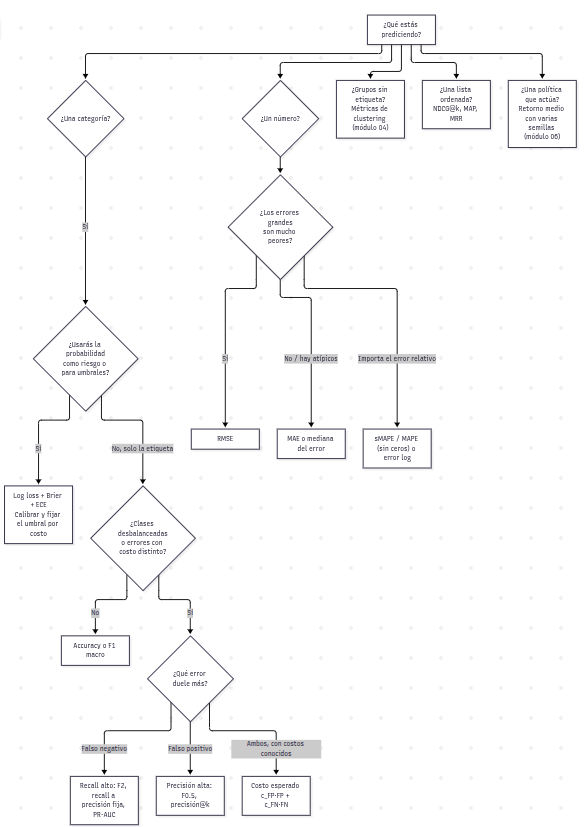

Cierra lo visto en las secciones 4 y 6: si la decisión final es **comparar un costo**, la probabilidad debe estar **calibrada**; con $c_{FP}=1$ y $c_{FN}=r$, el umbral que minimiza el costo esperado es $t^*=\frac1{1+r}$ **solo si** $\hat p$ es una probabilidad real. Lo comprobamos con los modelos de la sección 4: usamos el umbral teórico $t^*$ y lo comparamos con el **mejor umbral posible** (referencia que mira la prueba, solo para medir cuánto se pierde).

In [ ]:
# ============================================================
# 7. Del costo del negocio a la decision: umbral teorico vs. probabilidades (des)calibradas
# ============================================================
# Costo de un FP = 1; costo de un FN = r. Con probabilidades CALIBRADAS el umbral que minimiza el costo esperado es t* = 1 / (1 + r).
def costo_por_1000(y_verd, p, umbral, r):
    pred = p >= umbral
    fp, fn = np.sum(pred & (y_verd == 0)), np.sum(~pred & (y_verd == 1))
    return 1000 * (fp + r * fn) / len(y_verd)

umbrales = np.linspace(0.005, 0.995, 199)
filas = []
for r in (1, 5, 20):
    t_star = 1 / (1 + r)
    for modelo_ in ("Naive Bayes", "Bosque aleatorio"):
        for variante in ("cruda", "Platt (sigmoid)"):
            p = probas[(modelo_, variante)]
            c_teorico = costo_por_1000(yc_te, p, t_star, r)
            c_optimo = min(costo_por_1000(yc_te, p, t, r) for t in umbrales)           # referencia 'oraculo' (umbral elegido mirando la prueba)
            filas.append({"costo FN / FP": r, "modelo": modelo_, "probabilidades": variante, "umbral teórico t*": f"{t_star:.3f}",
                          "costo con t* (por 1000)": c_teorico, "mejor costo posible": c_optimo, "exceso": c_teorico - c_optimo})
tab_c = pd.DataFrame(filas)
display(tab_c.round(1).set_index(["costo FN / FP", "modelo", "probabilidades"]))

# Con Platt el umbral teorico queda mas cerca del oraculo que con las probabilidades crudas (promedio sobre los escenarios)
exceso = tab_c.groupby(["modelo", "probabilidades"])["exceso"].mean()
print("\nExceso medio de costo respecto al mejor umbral posible (por 1000 casos):")
print(exceso.round(1).to_string())
assert exceso[("Naive Bayes", "Platt (sigmoid)")] < exceso[("Naive Bayes", "cruda")]

fig, ax = plt.subplots(figsize=(9, 4.6))
for modelo_, col in [("Naive Bayes", "#dc2626"), ("Bosque aleatorio", "#16a34a")]:
    for variante, ls in [("cruda", "--"), ("Platt (sigmoid)", "-")]:
        p = probas[(modelo_, variante)]
        ax.plot(umbrales, [costo_por_1000(yc_te, p, t, 5) for t in umbrales], ls, color=col, lw=2, label=f"{modelo_} · {variante}")
ax.axvline(1 / 6, color="black", ls=":", label="Umbral teórico $t^*=1/(1+r)$ con $r=5$")
ax.set_xlim(0, 0.7); ax.set_ylim(100, 1000)
ax.set_xlabel("Umbral de decisión"); ax.set_ylabel("Costo por 1 000 casos (FP = 1, FN = 5)")
ax.set_title("El umbral teórico solo funciona con probabilidades calibradas", fontweight="bold"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Moraleja: la métrica correcta sale del COSTO del negocio; si decides con probabilidades, calíbralas primero (sección 4) y elige el umbral en validación, no en prueba (módulo 03, cuaderno 00).")

---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Protocolo** | Separar la **prueba** primero y **sellarla**; elegir con validación o CV; reentrenar con todo el desarrollo y evaluar **una sola vez**. Siempre con **línea base** (clase mayoritaria, azar, media, persistencia) |
| **Incertidumbre** | Toda métrica es una **estimación con ruido**: reporta **IC** (bootstrap sirve para cualquier métrica; Wilson para proporciones). El ancho decrece como $1/\sqrt n$ |
| **Comparar modelos** | La *t* pareada sobre pliegues es **optimista** (pliegues correlacionados); con 30 remuestras 90/10 declaró «diferencia» **~1 de cada 3** veces sin haberla. **Nadeau-Bengio** la calibra; **McNemar** y **5×2cv** son alternativas con error tipo I controlado |
| **Si no hay diferencia clara** | Elige el modelo **más simple, rápido y barato**; la complejidad extra no está justificada por la evidencia |
| **Probabilidades** | **Log loss** y **Brier** son reglas **propias**; calibración $\neq$ discriminación. **Platt** (robusta) e **isotónica** (flexible, sobreajusta con pocos datos) con `CalibratedClassifierCV` |
| **Curvas de aprendizaje** | Convergen bajo → **sesgo**; gran brecha → **varianza**; la validación aún sube → **más datos** |
| **Elegir la métrica** | Parte de la **pregunta y el costo de los errores**; la tabla guía cubre clasificación, regresión, *clustering* (M04), *ranking* y refuerzo (M06) |
| **Costo y umbral** | $t^*=1/(1+r)$ solo vale con probabilidades **calibradas**; elige el umbral en **validación**, no en prueba |

> 🎓 **Siguiente paso:** el [cuaderno 01](01_Validacion_Cruzada_Avanzada.ipynb) lleva la validación cruzada a su nivel avanzado (grupos, series de tiempo, **validación anidada**); después, la búsqueda de hiperparámetros ([cuaderno 02](02_Random_Search_y_GridSearch.ipynb) y [03](03_Optimizacion_Bayesiana.ipynb)).

---
### 🧠 Autoevaluación

1. Un equipo reporta «nuestro modelo alcanza 96.1 % frente a 95.3 % del modelo actual» sobre una prueba de 300 casos. ¿Qué información falta para decidir si esa diferencia es real? Describe **dos** procedimientos (uno con IC y otro con una prueba pareada) y qué supuesto hace cada uno.
2. Explica con tus palabras por qué los $k$ puntajes de una validación cruzada **no son independientes** y cómo eso vuelve **demasiado optimista** a la *t* pareada. ¿Qué cambia exactamente en la fórmula de Nadeau y Bengio y por qué el factor depende de $n_{\text{prueba}}/n_{\text{ent}}$?
3. Con $b=12$ y $c=3$ en McNemar, ¿qué significan esos números? ¿Por qué los ejemplos en los que ambos modelos aciertan no aportan información? ¿Qué **no** captura McNemar que sí captura la 5×2cv?
4. Un modelo de riesgo de crédito tiene un ROC-AUC excelente pero su diagrama de confiabilidad está muy por debajo de la diagonal. ¿Puedes usar sus probabilidades para calcular la pérdida esperada de una cartera? ¿Qué harías antes (y con qué datos)?
5. Tu curva de aprendizaje muestra entrenamiento en 0.99 y validación en 0.80, con la validación aún creciendo al final. ¿Qué dos acciones probarías y cuál tiene más probabilidad de ayudar? ¿Qué cambiaría si ambas curvas estuvieran planas en 0.80?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>